<a href="https://colab.research.google.com/github/laryferreira/ieeecisIA/blob/studies/StudentsHabits_IEEECis_LaryssaFerreira.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Horas em redes sociais**

Por meio do gráfico de dispersão, foi possível interpretar dificilmente alunos com notas altas passam mais de 4 horas em redes sociais.

# Desafio Students Habits x Academic Performance - IEEE Computer Society
*   Laryssa de Oliveira Ferreira
*   222005386

## Descrição do desafio:

Utilizando como base o dataset Student Habits vs Academic Performance:

✅ Apenas com a observação dos dados por meio de tabelas e dataframe,
apresente suas hipóteses;

✅ Realize uma EDA da forma que julgar mais adequada;

✅ Com base na EDA realizada, revise as suas hipóteses a respeito do dados;

✅ Construa um algoritmo de K-Means from scratch utilizando a linguagem
Python;

✅ Apresente a justificativa de forma discursiva e por meio de cálculos, o valor
de K utilizado;

✅ Revise as hipóteses levantadas no exercício 1 e 2 e com base no algoritmo
desenvolvido, apresente análise crítica a respeito das informações extraídas
dos dados caso o algoritmo refute ou confirme suas hipóteses;

Tarefas Extra:

Exercite sua habilidade de pesquisa e curadoria de informações e a partir de
fontes próprias, escreva, com suas palavras, de maneira teórica e com o
aprofundamento que achar adequado os algoritmos DBSCAM e Hierarquical
Clustering;

Exercite sua habilidade de pesquisa e curadoria de informações e a partir de
fontes próprias, escreva, com suas palavras, de maneira teórica e com o
aprofundamento que achar adequado qual o algoritmo state-of-the-art para
Clustering. Apresente as referências utilizadas.

## **1. Análise Exploratória dos dados por meio de tabelas e dataframes**

**1.1 Importação das bibliotecas, carregamento do csv e visualização das colunas**

In [216]:
import pandas as pd

In [217]:
file_path = "student_habits_performance.csv"

try:
  df = pd.read_csv(file_path, sep=',')
  print(df)

  print("Colunas do dataset:")
  print(df.columns)

except FileNotFoundError:
    print(f"\nERRO: O arquivo '{file_path}' não foi encontrado.")

    student_id  age  gender  study_hours_per_day  social_media_hours  \
0        S1000   23  Female                  0.0                 1.2   
1        S1001   20  Female                  6.9                 2.8   
2        S1002   21    Male                  1.4                 3.1   
3        S1003   23  Female                  1.0                 3.9   
4        S1004   19  Female                  5.0                 4.4   
..         ...  ...     ...                  ...                 ...   
995      S1995   21  Female                  2.6                 0.5   
996      S1996   17  Female                  2.9                 1.0   
997      S1997   20    Male                  3.0                 2.6   
998      S1998   24    Male                  5.4                 4.1   
999      S1999   19  Female                  4.3                 2.9   

     netflix_hours part_time_job  attendance_percentage  sleep_hours  \
0              1.1            No                   85.0        

Como foi visto, esse é um dataset com 1000 linhas e 16 colunas, cada uma representando um estudante e as suas respectivas informações, além da variável principal que queremos comparar, que é a nota final no exame.

## **1.2 Recortes do data frame por meio de correlações e agrupamentos**

**1.2.1 - Correlação simples dos principais hábitos que influenciam a nota.**

**Análise**

Aqui podemos perceber que as colunas com correlação + perto de 1 (horas de estudo e saúde mental) costumam ter relação diretamente proporcional com a variável analisada, ou seja, estudantes com melhor saúde mental e horas de estudo possuem notas maiores nas provas.

Da mesma forma, as variáveis com correlação perto de 0 não costumam influenciar a variável analisada, ou seja, a presença é um dos fatores que não corrobora para a nota.

Já as correlações negativas costumam seguir o padrão de inversamente proporcionais em relação à variável analisada. Ou seja, estudantes que passam mais horas nas redes sociais e netflix costumam ter pior desempenho nas provas.

In [218]:
df.corr(numeric_only=True)['exam_score'].sort_values(ascending=False)

,exam_score
exam_score,1.000000
study_hours_per_day,0.825419
mental_health_rating,0.321523
exercise_frequency,0.160107
sleep_hours,0.121683
attendance_percentage,0.089836
age,-0.008907
social_media_hours,-0.166733
netflix_hours,-0.171779


**1.2.2 - Análise das médias por agrupamento**

**Idade**

Aqui percebemos que a idade dos estudantes do csv varia entre 17 e 24, o que indica que estão finalizando o ensino médio ou no ensino superior. Como visto acima, a idade é um fator perto de 0 na correlação, o que implica que não é um fator crucial.

In [219]:
df.groupby('age')['exam_score'].mean()

,exam_score
age,
17,70.342857
18,70.939316
19,68.293805
20,69.919863
21,67.544000
22,69.102655
23,70.901681
24,69.638806


**Tempo gasto em redes sociais**

Quanto mais tempo nas redes sociais, menor a nota dos estudantes.

In [220]:
df.groupby('social_media_hours')['exam_score'].mean()

,exam_score
social_media_hours,
0.0,76.028571
0.1,67.966667
0.2,75.625000
0.3,75.550000
0.4,70.150000
0.5,81.533333
0.6,74.300000
0.7,72.880000
0.8,70.310000


**Participação em extracurriculares**

Também é um fator pouco determinante para a nota da prova.

In [221]:
df.groupby('extracurricular_participation')['exam_score'].mean()

,exam_score
extracurricular_participation,
No,69.591349
Yes,69.623270


**Tempo gasto em Netflix**

Quanto mais tempo na Netflix, menor a nota dos estudantes. Porém, é importante ver que os estudantes com maiores horas estão também se dando bem nos exames.

In [222]:
df.groupby('netflix_hours')['exam_score'].mean()

,exam_score
netflix_hours,
0.0,75.728814
0.1,72.708333
0.2,78.972727
0.3,75.370588
0.4,76.405882
0.5,73.028571
0.6,74.710526
0.7,68.842857
0.8,70.866667


**Gênero**

O gênero foi pouco determinante, sendo que mulheres e "outros" se saíram pouco melhores que os homens.

In [223]:
df.groupby('gender')['exam_score'].mean()

,exam_score
gender,
Female,69.741372
Male,69.368344
Other,70.647619


**Qualidade da dieta**

Também um fator de pouca importância.

In [224]:
df.groupby('diet_quality')['exam_score'].mean()


,exam_score
diet_quality,
Fair,70.428833
Good,69.366402
Poor,68.127568


**Qualidade da internet**

Também um fator de pouca importância.

In [225]:
df.groupby('internet_quality')['exam_score'].mean()

,exam_score
internet_quality,
Average,70.643990
Good,68.647651
Poor,69.717284


**Horas de Estudo**

O fator de maior importância dentre os analisados. É certo que quanto mais horas dedicadas, maior a nota do estudante.

In [226]:
df.groupby('study_hours_per_day')['exam_score'].mean()

,exam_score
study_hours_per_day,
0.0,40.807692
0.1,53.400000
0.2,31.500000
0.3,32.625000
0.5,39.525000
...,...
7.4,99.233333
7.5,100.000000
7.6,100.000000


**Escolaridade dos pais**

Também um fator de pouca importância.

In [227]:
df.groupby('parental_education_level')['exam_score'].mean()

,exam_score
parental_education_level,
Bachelor,70.272571
High School,69.547194
Master,68.086826


**1.2.3 - Hipótese**


---


A minha hipótese, por meio dos dados apresentados, é que os principais hábitos de estudantes de sucesso é uma combinação das horas de estudo com uma saúde mental de qualidade e um afastamento das redes sociais e de distrações com streaming.

##**2. Análise Exploratória dos Dados - EDA**

**2.1.1 Importação das bibliotecas para gerar os gráficos**

In [228]:
import matplotlib.pyplot as plt
import seaborn as sns

**Distribuição de Notas**

A grande parte dos alunos está acima da nota 50 no exame, mais concentrados entre 60 e 70. A partir de 80, a frequência de alunos cai, mas se eleva novamente nos que gabaritaram. Me parece um dataset com muitos alunos bons :)

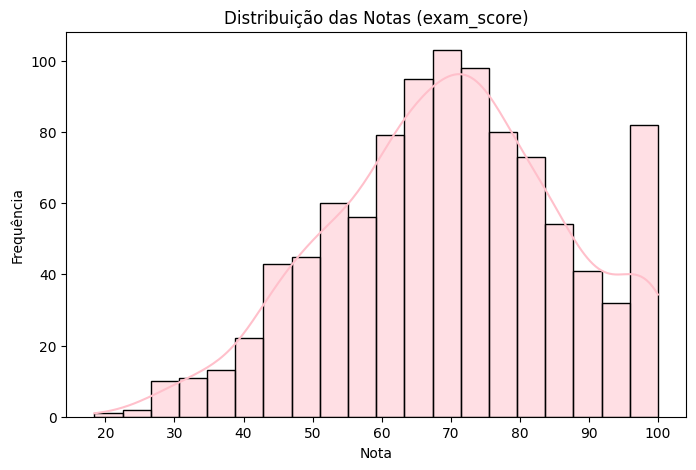

In [229]:
plt.figure(figsize=(8,5))
sns.histplot(df['exam_score'], kde=True, bins=20, color='pink')
plt.title('Distribuição das Notas (exam_score)')
plt.xlabel('Nota')
plt.ylabel('Frequência')
plt.show()

**Gênero**

Em dados categóricos, eu usarei boxplots para auxiliar na visualização em relação à variável numérica da nota da prova. Isso permite aprofundar na relação que encontrei com a correlação realizada na etapa 1.2.2. Aqui, percebemos também que os alunos identificados com "outros" também não tem notas muito baixas, enquanto homens e mulheres costumam ter notas abaixo de 30 até 100.

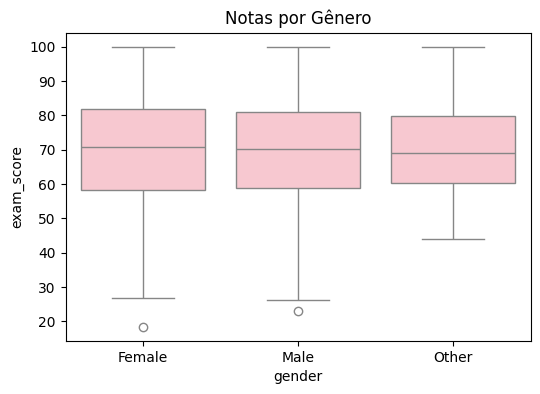

In [230]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='gender', y='exam_score', color='pink')
plt.title('Notas por Gênero')
plt.show()

**Qualidade da dieta**

Da mesma forma, com boxplots eu consegui perceber que a média de estudantes com a dieta ruim é ligeiramente menor, ficando abaixo dos 60 pontos, enquanto estudantes com dieta boa e excelente ficam acima dos 70.

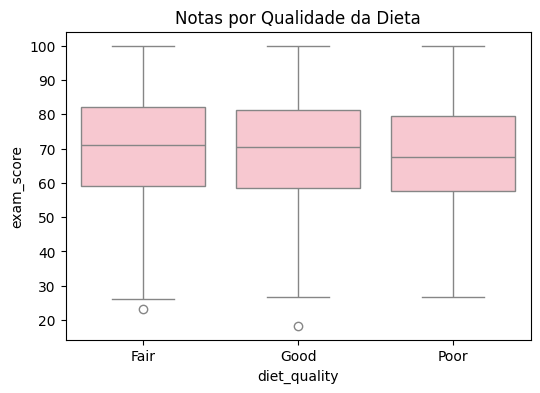

In [231]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='diet_quality', y='exam_score', color='pink')
plt.title('Notas por Qualidade da Dieta')
plt.show()

**Classificadores de saúde mental**

É bem interessante perceber que as notas no exame crescem como uma escada ao serem comparadas com a "qualidade" de saúde mental. Por isso percebemos que é um dos principais fatores a serem considerados nessa análise.

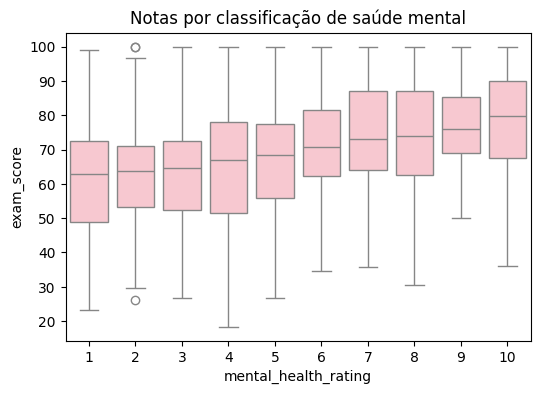

In [232]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='mental_health_rating', y='exam_score', color='pink')
plt.title('Notas por classificação de saúde mental')
plt.show()

*Queria todos os gráficos rosa mas ficava bem ruim de visualizar kkkk*

*seguindo*

**Horas de Estudo**

Por meio do gráfico de dispersão com regressão linr=ear (regplot), foi possível interpretar que a nota cresce proporcionalmente ao número de horas de estudo por dia e é sim, o fator mais relevante.

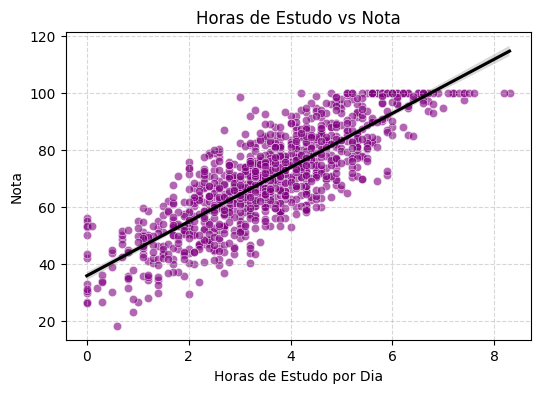

In [233]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='study_hours_per_day', y='exam_score', data=df, color='purple', alpha=0.6)
sns.regplot(x='study_hours_per_day', y='exam_score', data=df, scatter=False,
            line_kws={"color":"black"})
plt.title('Horas de Estudo vs Nota')
plt.xlabel('Horas de Estudo por Dia')
plt.ylabel('Nota')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Horas em redes sociais**

Por meio do gráfico de dispersão, foi possível interpretar dificilmente alunos com notas altas passam mais de 4 horas em redes sociais.

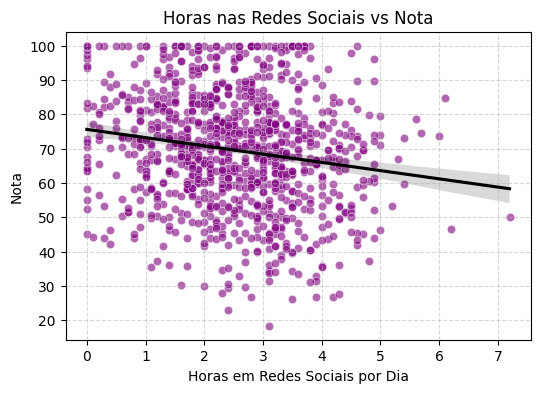

In [234]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='social_media_hours', y='exam_score', data=df, color='purple', alpha=0.6)
sns.regplot(x='social_media_hours', y='exam_score', data=df, scatter=False,
            line_kws={"color":"black"})
plt.title('Horas nas Redes Sociais vs Nota')
plt.xlabel('Horas em Redes Sociais por Dia')
plt.ylabel('Nota')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Horas em Netflix**

Por meio do gráfico de dispersão, foi possível interpretar que é, na verdade, uma variante um pouco menos influente. A ampla dispersão dos pontos sugere que o tempo de consumo de Netflix, por si só, não é um fator determinante ou um bom preditor do desempenho acadêmico neste conjunto de dados, apesar de obter o mesmo fator de correlação que redes sociais.

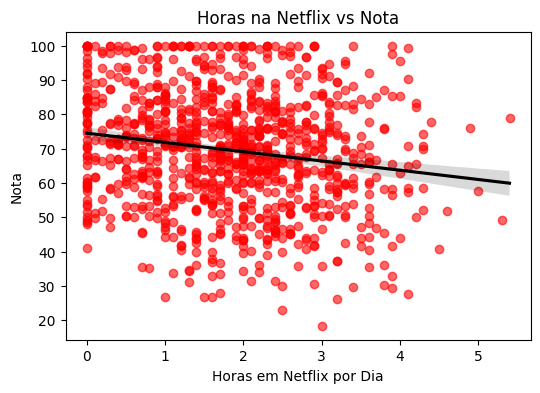

In [235]:
plt.figure(figsize=(6,4))
sns.regplot(x='netflix_hours', y='exam_score', data=df, color='red',
            line_kws={"color":"black"}, scatter_kws={'alpha':0.6})
plt.title('Horas na Netflix vs Nota')
plt.xlabel('Horas em Netflix por Dia')
plt.ylabel('Nota')
plt.show()

**Horas de Sono**

Por meio do gráfico de dispersão, foi possível interpretar que as horas de sono são também um fator importantíssimo para o aumento das notas no exame.

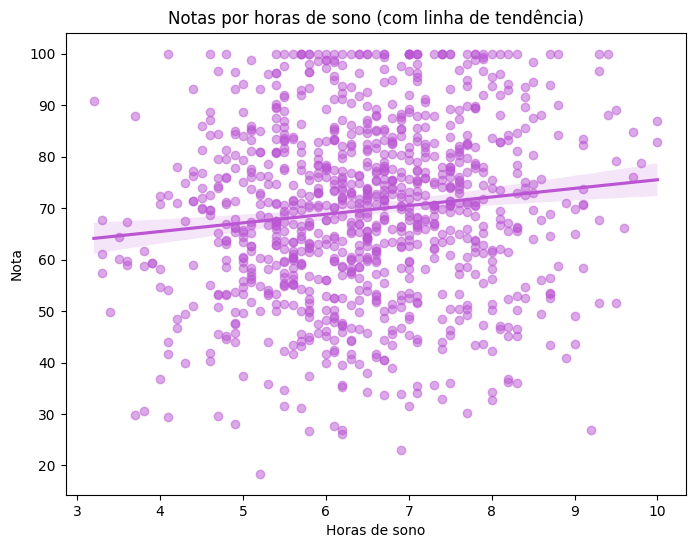

In [236]:
plt.figure(figsize=(8,6))
sns.regplot(data=df, x='sleep_hours', y='exam_score', scatter_kws={'alpha':0.5}, color='mediumorchid')
plt.title('Notas por horas de sono (com linha de tendência)')
plt.xlabel('Horas de sono')
plt.ylabel('Nota')
plt.show()

**Bônus: exploração que deu errado**

Percebendo horas de sono e saúde mental como elementos relevantes, pensei em correlacionar os dois, mas a correlação é quase zero mesmo hehe

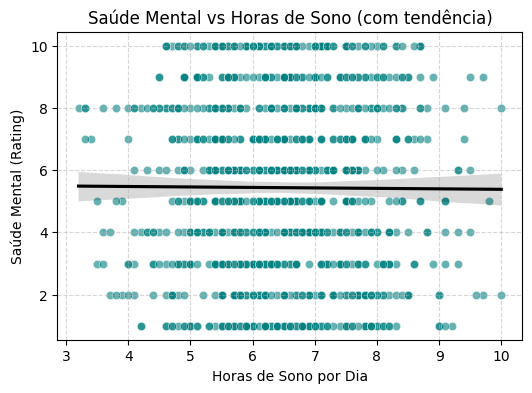

In [237]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='sleep_hours', y='mental_health_rating', data=df, color='teal', alpha=0.6)
sns.regplot(x='sleep_hours', y='mental_health_rating', data=df, scatter=False,
            line_kws={"color":"black"})
plt.title('Saúde Mental vs Horas de Sono (com tendência)')
plt.xlabel('Horas de Sono por Dia')
plt.ylabel('Saúde Mental (Rating)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [238]:
df[['sleep_hours', 'mental_health_rating']].corr()

,sleep_hours,mental_health_rating
sleep_hours,1.000000,-0.006508
mental_health_rating,-0.006508,1.000000


**Mapa de Calor**

Por meio do mapa de calor, podemos visualizar de maneira mais destacada os fatores que observamos na seção 1.2.1, com as correlações entre as variáveis e a nota do exame.

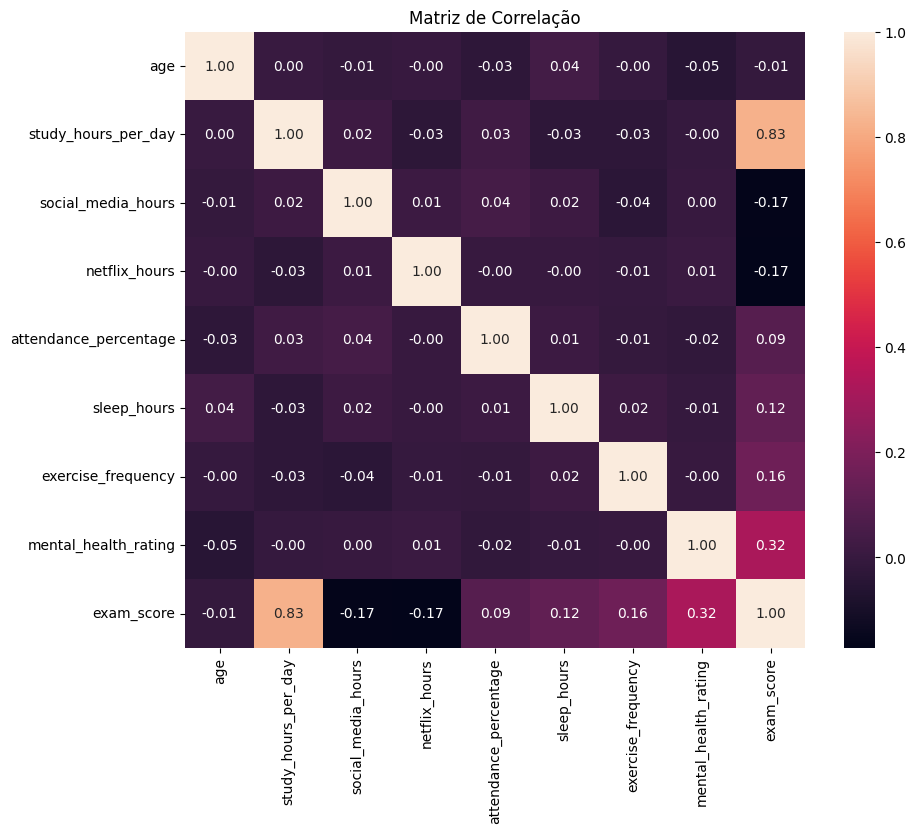

In [239]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")
plt.title('Matriz de Correlação')
plt.show()

**2.1.2 - Hipótese modificada**


---


A minha hipótese, por meio dos dados apresentados, é que os principais hábitos de estudantes de sucesso é uma combinação das horas de estudo com uma saúde mental de qualidade. Hora de sono também é relevante e horas em redes sociais e netflix impactam negativamente as notas.

##**3. Implementação do K-Means do zero e análise dos resultados**

**Relembrando...o que é K-means?**

K-Means é um algoritmo de agrupamento não supervisionado, usado para separar dados em grupos (clusters) que tenham características semelhantes.

É muito usado em análise exploratória de dados, segmentação de clientes, compressão de dados, recomendação, entre outros.


**Exemplo simples:**

A nossa base contém:

Horas de estudo por dia

Horas em redes sociais

O K-Means pode agrupar os estudantes em:

Cluster 1: Estudantes que estudam muito e usam pouco redes sociais.

Cluster 2: Estudantes que estudam pouco e usam muito redes sociais.

Cluster 3: Grupo intermediário.



**3.1 - Implementação do K-means. *Utilizei o gemini para me ajudar a encontrar as funções no numpy, mas não foi muito útil e fui na documentação mesmo.***

In [240]:
# importar bibliotecas essenciais
import numpy as np # numpy pra manipulação numérica consumir menos memória
import pandas as pd #pandas pra lidar com os dataframes
import matplotlib.pyplot as plt #matplotlib para plotar os gráficos

# tratamento do csv
file_path = '/content/student_habits_performance.csv'
df = pd.read_csv(file_path, sep=',')

#dataframe do array de colunas que serão comparadas
X = df[['exam_score', 'social_media_hours']].values

def kmeans(X, k, max_iters=100): # X já definimos, k definiremos depois
    np.random.seed(42) # inicializar centróides aleatoriamente
    centroids = X[np.random.choice(len(X), k, replace=False)] # aqui, o que estamos fazendo é pegando um ponto aleatório entre as linhas existentes em X para ser nossos centróides,
    #e o replace false indica que queremos evitar que os centróides sejam os mesmos nesse início.

    for _ in range(max_iters):
        # calcula distâncias entre pontos e centróides
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        # np.newaxis: aumenta uma dimensão para permitir a subtração de matrizes
        # subtrai cada ponto de x com cada centróide
        # calcula a distância euclidiana entre cada um dos pontos

        # atribui cada ponto ao cluster mais próximo para sua identificação
        labels = np.argmin(distances, axis=1) #labels: vetor que indica a qual cluster pertence

        # calcula novos centróides
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])
        # o K-Means busca colocar o centróide no centro de massa dos pontos atribuídos a ele, por isso usamos a média
        # isso faz com que os clusters sejam ajustados iterativamente até estabilizarem.

        # se os centróides não mudarem, parar
        if np.all(centroids == new_centroids):
            break
        centroids = new_centroids

    return centroids, labels # retorna os centróides e os clusters

# rodar o K-Means
k = 2 #encontrado pelo método do cotovelo
centroids, labels = kmeans(X, k)


**3.1.1 - Plotagem do gráfico**

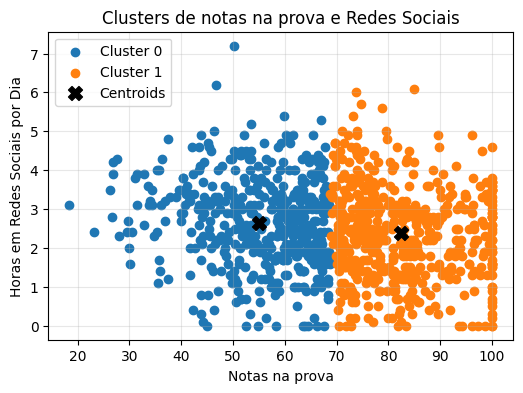

In [241]:
plt.figure(figsize=(6, 4))
for i in range(k):
    plt.scatter(X[labels == i, 0], X[labels == i, 1], label=f'Cluster {i}')
plt.scatter(centroids[:, 0], centroids[:, 1], color='black', marker='X', s=100, label='Centroids')
plt.xlabel('Notas na prova')
plt.ylabel('Horas em Redes Sociais por Dia')
plt.title('Clusters de notas na prova e Redes Sociais')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

O gráfico mostra como o algoritmo K-Means conseguiu agrupar os indivíduos em dois grupos distintos com base nas horas de redes sociais e notas. Existe uma separação visual evidente entre aqueles que estudam menos e aqueles que estudam mais.

É interessante que, para ambos os clusters, a distribuição é bastante dispersa, sugerindo que, ter melhores ou piores notas não determina, por si só, se a pessoa usa muito ou pouco as redes sociais, dentro da lógica desses dois agrupamentos.

**3.1.2 - WSS (Within-Cluster Sum of Squares) para diferentes valores de K**

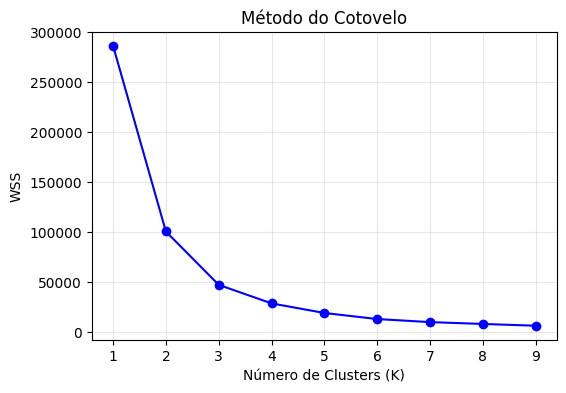

In [242]:
wss = []
K_range = range(1, 10)

for k in K_range:
    centroids, labels = kmeans(X, k) #algoritmo anterior
    #print(X)
    distances = np.linalg.norm(X - centroids[labels], axis=1) #calcula as distâncias dos pontos aos centróides
    wss.append(np.sum(distances**2)) #insere na lista a soma das distâncias ao quadrado

plt.figure(figsize=(6, 4))
plt.plot(K_range, wss, 'bo-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WSS')
plt.title('Método do Cotovelo')
plt.grid(alpha=0.3)
plt.show()

In [243]:
# importar bibliotecas essenciais
import numpy as np # numpy pra manipulação numérica consumir menos memória
import pandas as pd #pandas pra lidar com os dataframes
import matplotlib.pyplot as plt #matplotlib para plotar os gráficos

# tratamento do csv
file_path = '/content/student_habits_performance.csv'
df = pd.read_csv(file_path, sep=',')

#dataframe do array de colunas que serão comparadas
W = df[['exam_score', 'study_hours_per_day']].values

def kmeans(X, k, max_iters=100): # W já definimos, k definiremos depois
    np.random.seed(42) # inicializar centróides aleatoriamente
    centroids = X[np.random.choice(len(W), k, replace=False)] # aqui, o que estamos fazendo é pegando um ponto aleatório entre as linhas existentes em X para ser nossos centróides,
    #e o replace false indica que queremos evitar que os centróides sejam os mesmos nesse início.

    for _ in range(max_iters):
        # calcula distâncias entre pontos e centróides
        distances = np.linalg.norm(W[:, np.newaxis] - centroids, axis=2)
        # np.newaxis: aumenta uma dimensão para permitir a subtração de matrizes
        # subtrai cada ponto de x com cada centróide
        # calcula a distância euclidiana entre cada um dos pontos

        # atribui cada ponto ao cluster mais próximo para sua identificação
        labels = np.argmin(distances, axis=1) #labels: vetor que indica a qual cluster pertence

        # calcula novos centróides
        new_centroids = np.array([W[labels == i].mean(axis=0) for i in range(k)])
        # o K-Means busca colocar o centróide no centro de massa dos pontos atribuídos a ele, por isso usamos a média
        # isso faz com que os clusters sejam ajustados iterativamente até estabilizarem.

        # se os centróides não mudarem, parar
        if np.all(centroids == new_centroids):
            break
        centroids = new_centroids

    return centroids, labels # retorna os centróides e os clusters

# rodar o K-Means
k = 2 #encontrado pelo método do cotovelo
centroids, labels = kmeans(W, k)


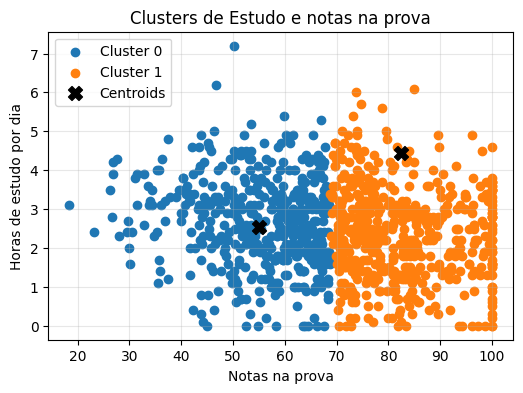

In [244]:
plt.figure(figsize=(6, 4))
for i in range(k):
    plt.scatter(X[labels == i, 0], X[labels == i, 1], label=f'Cluster {i}')
plt.scatter(centroids[:, 0], centroids[:, 1], color='black', marker='X', s=100, label='Centroids')
plt.xlabel('Notas na prova')
plt.ylabel('Horas de estudo por dia')
plt.title('Clusters de Estudo e notas na prova')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

O K-Means agrupou os alunos em dois segmentos distintos: um grupo de alunos com desempenho inferior a mediano (Cluster 0), que em média estuda menos, e um grupo de alunos com alto desempenho (Cluster 1), que em média dedica mais tempo aos estudos. Esta visualização reforça a ideia de que as horas de estudo são um fator crucial para o desempenho nas provas.

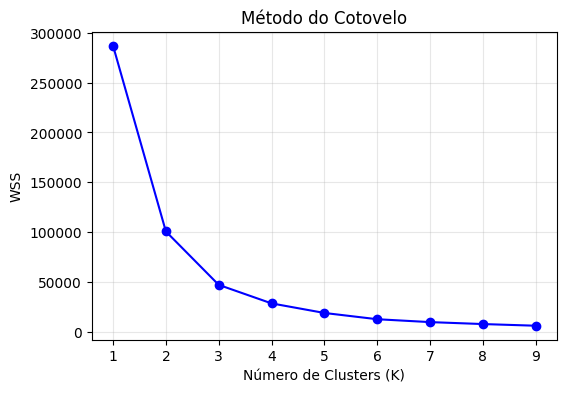

In [245]:
wss = []
K_range = range(1, 10)

for k in K_range:
    centroids, labels = kmeans(W, k) #algoritmo anterior
    #print(W)
    distances = np.linalg.norm(W - centroids[labels], axis=1) #calcula as distâncias dos pontos aos centróides
    wss.append(np.sum(distances**2)) #insere na lista a soma das distâncias ao quadrado

plt.figure(figsize=(6, 4))
plt.plot(K_range, wss, 'bo-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WSS')
plt.title('Método do Cotovelo')
plt.grid(alpha=0.3)
plt.show()

**3.2 - Hipótese final e análise crítica**

---

Tanto a EDA quanto a K-means confirmam que os principais fatores para o sucesso dos alunos no exame foram as horas de estudo. No entanto, a minha hipótese inicial foi refutada no ponto em que a dispersão entre os pontos analisados no uso de redes sociais e nas notas foi grande o bastante para não trazer clareza se realmente é um fator determinante. Afinal, como vimos nos clusters, alunos com notas altas também passaram bastante tempo nas redes sociais.



PS: *Não sei se fiz o método do cotovelo certo, me deixou com uma pulga atrás da orelha esses 2 K's com gráficos iguais...não identifiquei se foi um problema de nomeação de variáveis, mas acredito que não! Se puder me dar um feedback quanto a isso! Gostei muito desse desafio!*

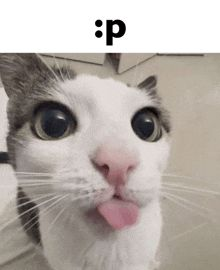